## Exercise 1: Word Frequency Counter

In [ ]:
text = "I like NLP I like Python NLP is fun"
word = text.split()
word

['I', 'like', 'NLP', 'I', 'like', 'Python', 'NLP', 'is', 'fun']

In [2]:
unique_word = set(word)
unique_word

{'I', 'NLP', 'Python', 'fun', 'is', 'like'}

In [3]:
for i in unique_word:
    print(i, word.count(i))

is 1
fun 1
Python 1
like 2
I 2
NLP 2


In [4]:
dict_word = {}
for i in unique_word:
    dict_word[i] = word.count(i)

dict_word

{'is': 1, 'fun': 1, 'Python': 1, 'like': 2, 'I': 2, 'NLP': 2}

In [5]:
print(dict_word)

{'is': 1, 'fun': 1, 'Python': 1, 'like': 2, 'I': 2, 'NLP': 2}


## Exercise 2: Vocabulary Builder

In [6]:
corpus = [
    "I like NLP",
    "I like AI",
    "AI is amazing"
    ]

In [7]:
corpus

['I like NLP', 'I like AI', 'AI is amazing']

In [8]:
passage = ' '.join(corpus)
passage

'I like NLP I like AI AI is amazing'

In [9]:
passage = passage.split()
passage


['I', 'like', 'NLP', 'I', 'like', 'AI', 'AI', 'is', 'amazing']

In [10]:
vocab = set(passage)
vocab

{'AI', 'I', 'NLP', 'amazing', 'is', 'like'}

In [11]:
print('vocabulary size is', len(vocab))

vocabulary size is 6


## Exercise 3: Build a Word Co-occurrence Matrix

In [236]:
sentence = "the cat sat on the mat"
sentence

'the cat sat on the mat'

In [237]:
words = (sentence.split())
words

['the', 'cat', 'sat', 'on', 'the', 'mat']

In [238]:
vocab = dict.fromkeys(words)
vocab


{'the': None, 'cat': None, 'sat': None, 'on': None, 'mat': None}

In [239]:
vocab = list(dict.fromkeys(words))
vocab



['the', 'cat', 'sat', 'on', 'mat']

In [240]:
indexs = {}
for index , i in enumerate(vocab):
    indexs[i] = index
indexs


{'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4}

In [241]:
size_matrix = len(vocab)
size_matrix

5

In [242]:
matrix = [[0 for _ in range(size_matrix)] for _ in range(size_matrix)]
matrix

[[0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0]]

In [243]:
index_word = {word: idx for idx, word in enumerate(vocab)}
index_word


{'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4}

In [244]:
indexs.keys()

dict_keys(['the', 'cat', 'sat', 'on', 'mat'])

In [245]:
list((indexs.values()))[0]

0

In [246]:
words

['the', 'cat', 'sat', 'on', 'the', 'mat']

In [247]:
vocab

['the', 'cat', 'sat', 'on', 'mat']

In [248]:
for i in range(len(words)):
    current = vocab.index(words[i])

    if i > 0:
        left = vocab.index(words[i-1])
        matrix[current][left] = 1

    if i < (len(words) - 1):
        right = vocab.index(words[i+1])
        matrix[current][right] = 1


In [249]:
matrix

[[0, 1, 0, 1, 1],
 [1, 0, 1, 0, 0],
 [0, 1, 0, 1, 0],
 [1, 0, 1, 0, 0],
 [1, 0, 0, 0, 0]]

## Exercise 4: Detect Data Sparsity

In [262]:
print("Word pairs never occurred")
for i in range(len(vocab)):
    for j in range(i+1, len(vocab)):
        if matrix[i][j] == 0:
            print(vocab[i],'<-->', vocab[j])

Word pairs never occurred
the <--> sat
cat <--> on
cat <--> mat
sat <--> mat
on <--> mat


## Exercise 5: Implement Laplace Smoothing

In [263]:
word_counts = {
    "cat":4,
    "dog":3,
    "bird":1
    }

In [264]:
word_counts

{'cat': 4, 'dog': 3, 'bird': 1}

In [266]:
value = word_counts.values()
value

dict_values([4, 3, 1])

In [268]:
total_value = sum(value)
total_value

8

In [269]:
vocab_size = len(word_counts)
vocab_size

3

In [272]:
for word in word_counts:
    probability = (word_counts[word] + 1) / (total_value + vocab_size)
    print(word, ":", round(probability, 3)  )

cat : 0.455
dog : 0.364
bird : 0.182


## Exercise 6: Simple Keyboard Prediction

In [158]:
from collections import defaultdict

In [284]:
corpus = [
    "I like NLP",
    "I like Python",
    "I like coffee",
    "I love NLP"
]

In [160]:
bigram_counts = defaultdict(lambda: defaultdict(int))
bigram_counts

defaultdict(<function __main__.<lambda>()>, {})

In [161]:
for sentence in corpus:
    words = sentence.split()

    for i in range(len(words)-1):
        current_word = words[i]
        next_word = words[i + 1]
        bigram_counts[current_word][next_word] += 1


In [162]:
bigram_counts

defaultdict(<function __main__.<lambda>()>,
            {'I': defaultdict(int, {'like': 3, 'love': 1}),
             'like': defaultdict(int, {'NLP': 1, 'Python': 1, 'coffee': 2}),
             'love': defaultdict(int, {'NLP': 1}),
             'You': defaultdict(int, {'like': 1})})

In [163]:
# text = input("Enter text: ").split()
text = "I like".split()
text

['I', 'like']

In [164]:
last_word = text[-1]
last_word

'like'

In [166]:
sorted(bigram_counts['like'].items(), key=lambda x: x[1],reverse=True)

[('coffee', 2), ('NLP', 1), ('Python', 1)]

In [168]:
if last_word in bigram_counts:

    prediction = sorted(bigram_counts[last_word].items(), key=lambda x: x[1],reverse=True)
    for word, count in prediction[:3]:
        print(word)
else:
    print('no suggestion found')

coffee
NLP
Python


## Exercise 7: Calculate TF-IDF

In [171]:
import math
from collections import Counter

In [181]:
documents = [
    "I like NLP like",
    "I like AI",
    "AI is amazing"
]

In [182]:
docs = [doc.split() for doc in documents]
docs

[['I', 'like', 'NLP', 'like'], ['I', 'like', 'AI'], ['AI', 'is', 'amazing']]

#### Calculate TF

In [183]:
tf = []
for i, doc in enumerate(docs):
    total_words = len(doc)
    word_counts = Counter(doc)

    tf_doc = {}
    for word in word_counts:
        tf_doc[word] = word_counts[word] / total_words
        print(f"TF for word '{word}' is {round(tf_doc[word], 2)}")
    tf.append(tf_doc)

TF for word 'I' is 0.25
TF for word 'like' is 0.5
TF for word 'NLP' is 0.25
TF for word 'I' is 0.33
TF for word 'like' is 0.33
TF for word 'AI' is 0.33
TF for word 'AI' is 0.33
TF for word 'is' is 0.33
TF for word 'amazing' is 0.33


#### Calculate DF.

In [184]:
df = {}

for doc in docs:
    for word in set(doc):
        df[word] = df.get(word, 0) + 1

for word, count in df.items():
    print(f"DF for word '{word}' is {count}")

DF for word 'like' is 2
DF for word 'NLP' is 1
DF for word 'I' is 2
DF for word 'AI' is 2
DF for word 'amazing' is 1
DF for word 'is' is 1


#### Calculate IDF.

In [186]:
df

{'like': 2, 'NLP': 1, 'I': 2, 'AI': 2, 'amazing': 1, 'is': 1}

In [188]:
N = len(docs)
idf = {}

for word, count in df.items():
    idf[word] = math.log10(N / count)
    print(f"IDF  '{word}' is {round(idf[word], 2)}")


IDF  'like' is 0.18
IDF  'NLP' is 0.48
IDF  'I' is 0.18
IDF  'AI' is 0.18
IDF  'amazing' is 0.48
IDF  'is' is 0.48


#### Compute TF-IDF.

In [195]:
for i, tf_doc in enumerate(tf):
    for word in tf_doc:
        tfidf = tf_doc[word] * idf[word]
        print(f"TF-IDF for word '{word}' in document '{i+1}' is {round(tfidf,2)}")

TF-IDF for word 'I' in document '1' is 0.04
TF-IDF for word 'like' in document '1' is 0.09
TF-IDF for word 'NLP' in document '1' is 0.12
TF-IDF for word 'I' in document '2' is 0.06
TF-IDF for word 'like' in document '2' is 0.06
TF-IDF for word 'AI' in document '2' is 0.06
TF-IDF for word 'AI' in document '3' is 0.06
TF-IDF for word 'is' in document '3' is 0.16
TF-IDF for word 'amazing' in document '3' is 0.16


## Exercise 8: Dense Vector Similarity

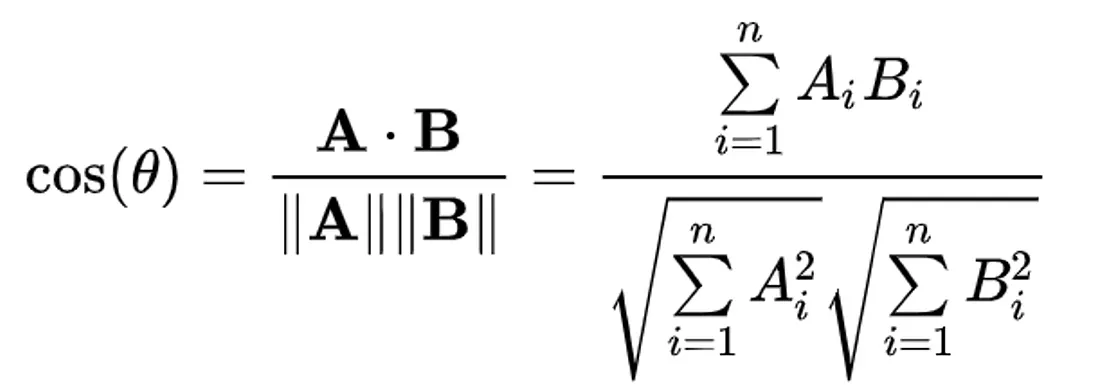

In [1]:
cat = [0.4,0.2,0.8]
dog = [0.5,0.1,0.7]

In [2]:
import numpy as np

In [3]:
cat_dot_dog = np.dot(cat, dog)
cat_dot_dog

np.float64(0.78)

In [4]:
cat_dot_dog = np.sum(np.multiply(cat,dog))
cat_dot_dog

np.float64(0.78)

In [5]:
mag_cat = np.linalg.norm(cat)
mag_dog = np.linalg.norm(dog)


In [6]:
mag_cat

np.float64(0.9165151389911681)

In [7]:
mag_dog

np.float64(0.8660254037844386)

In [8]:
cosine_similarity = cat_dot_dog / (mag_cat * mag_dog)
cosine_similarity

np.float64(0.9827076298239908)

## Exercise 9: Find Similar Words

In [12]:
import numpy as np
embeddings = {
    "cat":[0.4,0.2,0.8],
    "dog":[0.5,0.1,0.7],
    "car":[-0.7,0.8,-0.2],
    "lion":[0.45,0.25,0.82]
    }

In [13]:
embeddings['cat']

[0.4, 0.2, 0.8]

In [14]:
for i in embeddings:
    print(embeddings[i])

[0.4, 0.2, 0.8]
[0.5, 0.1, 0.7]
[-0.7, 0.8, -0.2]
[0.45, 0.25, 0.82]


In [36]:
#traget_word = input('Enter the word: ').lower().
traget_word = 'car'

In [37]:
traget_word

'car'

In [38]:
embeddings.items()

dict_items([('cat', [0.4, 0.2, 0.8]), ('dog', [0.5, 0.1, 0.7]), ('car', [-0.7, 0.8, -0.2]), ('lion', [0.45, 0.25, 0.82])])

In [40]:
sort_similarity = []
traget_vector = np.array(embeddings[traget_word])
for word, vector in embeddings.items():
    vector = np.array(vector)
    similarity = np.dot(traget_vector, vector) / (np.linalg.norm(traget_vector) * np.linalg.norm(vector))
    # print(f'{traget_word} & {word}:',similarity)
    sort_similarity.append((word, round(similarity,3)))
    
sort_similarity.sort(key=lambda x: x[1], reverse=True)
print(sort_similarity)



[('car', np.float64(1.0)), ('lion', np.float64(-0.266)), ('cat', np.float64(-0.282)), ('dog', np.float64(-0.438))]


In [46]:
sort_similarity[1][1].item()

-0.266

## Exercise 10 (Assignment) : Mini NLP Pipeline

In [47]:
import numpy as np
corpus = [
    "I love NLP",
    "I love AI",
    "AI loves Python",
    "Python loves data"
]


### 1. Build the vocabulary.

In [48]:
tokens = []

for sentence in corpus:
    tokens.extend(sentence.split())

tokens

['I',
 'love',
 'NLP',
 'I',
 'love',
 'AI',
 'AI',
 'loves',
 'Python',
 'Python',
 'loves',
 'data']

In [49]:
vocabulary = sorted(set(tokens))
vocabulary

['AI', 'I', 'NLP', 'Python', 'data', 'love', 'loves']

In [50]:
len(vocabulary)

7

### 2. Count Word Frequencies

In [ ]:

from collections import Counter

In [66]:
word_frequency = Counter(tokens)
word_frequency

Counter({'I': 2,
         'love': 2,
         'AI': 2,
         'loves': 2,
         'Python': 2,
         'NLP': 1,
         'data': 1})

In [68]:
for word, count in word_frequency.items():
    print(f"{word}: {count}")

I: 2
love: 2
NLP: 1
AI: 2
loves: 2
Python: 2
data: 1


### 3. Compute TF.

In [69]:
total_words = len(tokens)
total_words

12

In [74]:
for word in vocabulary:
    tf = word_frequency[word] / total_words
    print(f"{word}: {round(tf, 3)} words out of {total_words} total words")


AI: 0.167 words out of 12 total words
I: 0.167 words out of 12 total words
NLP: 0.083 words out of 12 total words
Python: 0.167 words out of 12 total words
data: 0.083 words out of 12 total words
love: 0.167 words out of 12 total words
loves: 0.167 words out of 12 total words


### 4. Build the co-occurrence matrix.

In [77]:
size = len(vocabulary)
word_index = {word: i for i, word in enumerate(vocabulary)}
word_index, size

({'AI': 0, 'I': 1, 'NLP': 2, 'Python': 3, 'data': 4, 'love': 5, 'loves': 6}, 7)

In [89]:
matrix = np.zeros((size, size), dtype=int)
matrix

array([[0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0]])

In [90]:
corpus

['I love NLP', 'I love AI', 'AI loves Python', 'Python loves data']

In [91]:
for sentence in corpus:
    words = sentence.split()

    for i in range(len(words) -1):
        w1 = words[i]
        w2 = words[i + 1]

        matrix[word_index[w1]][word_index[w2]] +=1

In [92]:
matrix

array([[0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 0]])

In [101]:
print("\nCo-occurrence Matrix")

print("      ", end="")
for word in vocabulary:
    print(f"{word:8}", end="")
print()

for i, word in enumerate(vocabulary):
    print(f"{word:6}", end=" ")
    for value in matrix[i]:
        print(f"{value:<8}", end="")
    print()


Co-occurrence Matrix
      AI      I       NLP     Python  data    love    loves   
AI     0       0       0       0       0       0       1       
I      0       0       0       0       0       2       0       
NLP    0       0       0       0       0       0       0       
Python 0       0       0       0       0       0       1       
data   0       0       0       0       0       0       0       
love   1       0       1       0       0       0       0       
loves  0       0       0       1       1       0       0       


### 5. Detect sparse entries.

In [103]:
for i in range(size):
    for j in range(size):
        if matrix[i][j] == 0 and i != j:
            print(f'{vocabulary[i]}, {vocabulary[j]}')

AI, I
AI, NLP
AI, Python
AI, data
AI, love
I, AI
I, NLP
I, Python
I, data
I, loves
NLP, AI
NLP, I
NLP, Python
NLP, data
NLP, love
NLP, loves
Python, AI
Python, I
Python, NLP
Python, data
Python, love
data, AI
data, I
data, NLP
data, Python
data, love
data, loves
love, I
love, Python
love, data
love, loves
loves, AI
loves, I
loves, NLP
loves, love


### 6. Apply Laplace smoothing to unigram probabilities.

In [106]:
vocab_size = size
vocab_size

7

In [108]:
for word in vocabulary:
    probability = (word_frequency[word] + 1) / (total_words + vocab_size)
    print(f"{word}: {probability:.4f}")

AI: 0.1579
I: 0.1579
NLP: 0.1053
Python: 0.1579
data: 0.1053
love: 0.1579
loves: 0.1579


### 7. Predict the next word after a user-entered word.

In [110]:
word_index

{'AI': 0, 'I': 1, 'NLP': 2, 'Python': 3, 'data': 4, 'love': 5, 'loves': 6}

In [129]:
#user_word = input("\nEnter a word: ")
user_word = 'love'

if user_word not in word_index:
    print('word not found')

else:
    row = matrix[word_index[user_word]]
    print(row)
    if row.sum() == 0:
        print('No prediction')

    else:
        indices = np.argsort(row)[::-1]
        print(indices)

        for idx in indices:
            if row[idx] > 0:
                print(vocabulary[idx])



[1 0 1 0 0 0 0]
[2 0 6 4 5 3 1]
NLP
AI


### 8. Display the top three most frequent words.

In [131]:
for word, count in word_frequency.most_common():
    print(word, ':', count)

I : 2
love : 2
AI : 2
loves : 2
Python : 2
NLP : 1
data : 1


## Exercise 11: Predict the Next Word Using Conditional Probability

In [133]:
from collections import defaultdict

In [132]:
corpus = [
    "I like NLP",
    "I like Python",
    "I like coffee",
    "I love NLP",
    "You like coffee"
]


In [134]:
bigram_counts = defaultdict(lambda: defaultdict(int))
word_counts = defaultdict(int)

for sentence in corpus:
    words = sentence.split()

    for i in range(len(words) - 1):
        w1 = words[i]
        w2 = words[i + 1]

        bigram_counts[w1][w2] += 1
        word_counts[w1] += 1


In [148]:
word_counts

defaultdict(int, {'I': 4, 'like': 4, 'love': 1, 'You': 1, 1: 0, 3: 0})

In [140]:
word_counts.items()

dict_items([('I', 4), ('like', 4), ('love', 1), ('You', 1), (1, 0), (3, 0)])

In [136]:
bigram_counts

defaultdict(<function __main__.<lambda>()>,
            {'I': defaultdict(int, {'like': 3, 'love': 1}),
             'like': defaultdict(int, {'NLP': 1, 'Python': 1, 'coffee': 2}),
             'love': defaultdict(int, {'NLP': 1}),
             'You': defaultdict(int, {'like': 1})})

In [142]:
w1

'like'

In [143]:
bigram_counts['love']

defaultdict(int, {'NLP': 1})

In [ ]:
for w1 in bigram_counts:
    for w2 in bigram_counts[w1]:
        print(f'{w1} -> {w2}: {bigram_counts[w1][w2]}')


I -> like: 3
I -> love: 1
like -> NLP: 1
like -> Python: 1
like -> coffee: 2
love -> NLP: 1
You -> like: 1


In [146]:
conditional_prob = defaultdict(dict)
conditional_prob

defaultdict(dict, {})

In [149]:
for w1 in bigram_counts:
    total = word_counts[w1]
    for w2 in bigram_counts[w1]:
        conditional_prob[w1][w2] = bigram_counts[w1][w2] / total

In [155]:
conditional_prob.items()

dict_items([('I', {'like': 0.75, 'love': 0.25}), ('like', {'NLP': 0.25, 'Python': 0.25, 'coffee': 0.5}), ('love', {'NLP': 1.0}), ('You', {'like': 1.0})])

In [151]:
for w1 in conditional_prob:
    for w2 in conditional_prob[w1]:
        print(f"P({w2} | {w1}) = {conditional_prob[w1][w2]:.2f}")

P(like | I) = 0.75
P(love | I) = 0.25
P(NLP | like) = 0.25
P(Python | like) = 0.25
P(coffee | like) = 0.50
P(NLP | love) = 1.00
P(like | You) = 1.00


In [157]:
#word = input("Enter a word: ")
word = 'like'
if word in conditional_prob:
    for next_word, prob in sorted(conditional_prob[word].items(), key=lambda x: x[1], reverse=True):
        print(f'{next_word} : {prob:.2f}')

    predicted = max(conditional_prob[word], key=conditional_prob[word].get)
predicted

coffee : 0.50
NLP : 0.25
Python : 0.25


'coffee'